# Class Imbalance Handling

In [7]:
# Core
import pandas as pd
import numpy as np

# Sklearn - Model & Evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import StandardScaler

# Imbalanced-learn - Resampling
from imblearn.pipeline import Pipeline          # Use this NOT sklearn's Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.under_sampling import RandomUnderSampler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# read 

train_preprocessed_df = pd.read_csv("../../data/preprocessed/train_preprocessed.csv") 
y_train = pd.read_csv("../../data/preprocessed/train_label_preprocessed.csv")

train_preprocessed_df.head(5)

,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,age,bmi,HbA1c_level,blood_glucose_level,...,age_hba1c_interaction,age_bmi_interaction,bmi_hba1c_interaction,age_glucose_interaction,gender,hypertension,heart_disease,high_hba1c_flag,senior_flag,cardio_risk_flag
0,0.0,0.0,1.0,0.0,0.0,0.0,0.361862,-0.795349,0.142857,-0.847458,...,-0.239693,-0.500569,-0.251066,-0.512287,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.261762,0.000000,0.000000,-0.847458,...,-0.489933,-0.563572,0.157075,-0.648393,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.724725,-0.682171,0.142857,-0.932203,...,0.594439,0.118586,-0.180452,-0.073724,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.712212,0.000000,0.857143,0.000000,...,0.838926,0.324306,0.685615,0.502836,1.0,1.0,0.0,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.436937,0.000000,-1.642857,-0.237288,...,-0.486577,-0.218286,-0.855959,-0.172023,0.0,0.0,0.0,0.0,0.0,0.0


Graph Correlation Matrix to visualize features to remove

<Axes: >

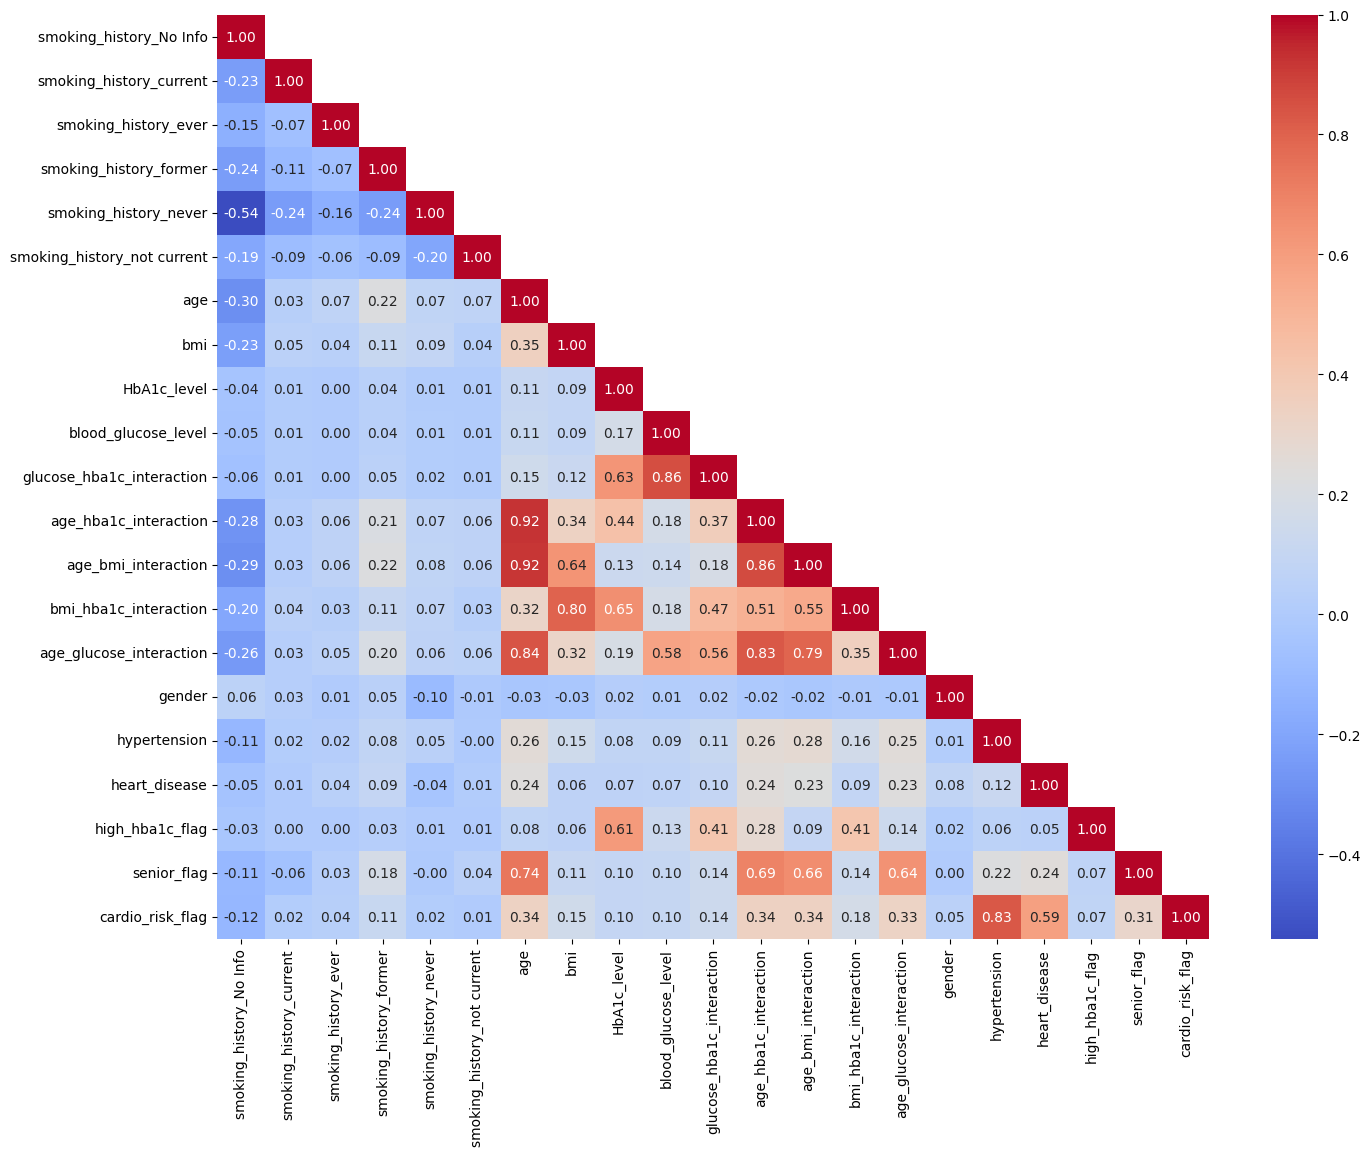

In [9]:
corr_matrix = train_preprocessed_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt=".2f")

feature selection
- age is chosen instead of ```age_hba1c_interaction``` ```age_bmi_interaction``` and ```age_glucose_interaction```
- hypertension chosen instead of ``` cardio_risk_flag ```

In [10]:
corr_matrix = corr_matrix.abs()  # abs() catches negative correlations too

upper_triangle = corr_matrix.where(
    mask.astype(bool)
)

to_drop = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] >= 0.8)
]

print(f"Features to drop: {to_drop}")

cleared = train_preprocessed_df.drop(columns=to_drop)
print(f"Remaining features: {cleared.columns.tolist()}")

Features to drop: ['glucose_hba1c_interaction', 'age_hba1c_interaction', 'age_bmi_interaction', 'age_glucose_interaction', 'cardio_risk_flag']
Remaining features: ['smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current', 'age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'bmi_hba1c_interaction', 'gender', 'hypertension', 'heart_disease', 'high_hba1c_flag', 'senior_flag']


In [11]:
X_train = cleared
y_train = pd.read_csv("../../data/preprocessed/train_label_preprocessed.csv")

X_test = pd.read_csv("../../data/preprocessed/validation_preprocessed.csv")
y_test = pd.read_csv("../../data/preprocessed/validation_label_preprocessed.csv")

# Align test to train columns exactly
X_test = X_test[X_train.columns]

# Fix the y shape warning too
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()
 

In [12]:
baselines = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
}

print("Train features:", X_train.columns.tolist())
print("Test features:", X_test.columns.tolist())

for name, model in baselines.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("AUC-ROC:", roc_auc_score(y_test, y_proba))

Train features: ['smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current', 'age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'bmi_hba1c_interaction', 'gender', 'hypertension', 'heart_disease', 'high_hba1c_flag', 'senior_flag']
Test features: ['smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current', 'age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'bmi_hba1c_interaction', 'gender', 'hypertension', 'heart_disease', 'high_hba1c_flag', 'senior_flag']

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     13145
           1       0.43      0.90      0.58      1273

    accuracy                           0.89     14418
   macro avg       0.71      0.89      0.76     14418
weighted avg       0.94      0.89      0.90   

Logistic Regression

Precision = 0.43 → flags 100 people as diabetic → only 43 actually are

Recall    = 0.90 → out of 1,273 diabetics → catches 1,145 of them

Overly cautious doctor sends everyone for testing, misses very few but causes a lot of unnecessary panic

Random Forest

Precision = 0.94 → flags 100 people as diabetic → 94 actually are

Recall    = 0.68 → out of 1,273 diabetics → catches 866, MISSES 407

Personality: Overconfident doctor very accurate when he says diabetic, but lets too many diabetics walk out undiagnosed

Recall

"Of everyone who ACTUALLY HAS diabetes, how many did the model catch?"

Random Forest minority recall = 0.68
→ Out of 1,273 actual diabetics in test set
→ Model caught 866 of them ✅
→ Model MISSED 407 real diabetics ❌

In [13]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

strategies = {
    'SMOTE': SMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
}

results = []

for name, sampler in strategies.items():
    print(f"\nRunning {name}...")
    
    # Resample ONLY train data
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    
    # Train model
    model = RandomForestClassifier(class_weight='balanced', random_state=42)
    model.fit(X_resampled, y_resampled)
    
    # Evaluate on ORIGINAL test data (never resampled)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred))
    
    # Store key numbers for comparison
    from sklearn.metrics import recall_score, precision_score, f1_score
    results.append({
        'Strategy': name,
        'Recall': recall_score(y_test, y_pred, pos_label=1),
        'Precision': precision_score(y_test, y_pred, pos_label=1),
        'F1': f1_score(y_test, y_pred, pos_label=1),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })

# Final comparison table
results_df = pd.DataFrame(results)
print("\n===== FINAL COMPARISON =====")
print(results_df.to_string(index=False))


Running SMOTE...
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     13145
           1       0.78      0.73      0.75      1273

    accuracy                           0.96     14418
   macro avg       0.87      0.86      0.87     14418
weighted avg       0.96      0.96      0.96     14418


Running SMOTETomek...
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     13145
           1       0.76      0.73      0.75      1273

    accuracy                           0.96     14418
   macro avg       0.87      0.86      0.86     14418
weighted avg       0.96      0.96      0.96     14418


Running SMOTEENN...
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     13145
           1       0.58      0.82      0.68      1273

    accuracy                           0.93     14418
   macro avg       0.78      0.88      0.82     14418
weighted avg

In [14]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

strategies = {
    'SMOTE': SMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
}

results = []

for name, sampler in strategies.items():
    print(f"\nRunning {name}...")
    
    # Resample ONLY train data
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    
    # Train model
    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    model.fit(X_resampled, y_resampled)
    
    # Evaluate on ORIGINAL test data (never resampled)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred))
    
    # Store key numbers for comparison
    from sklearn.metrics import recall_score, precision_score, f1_score
    results.append({
        'Strategy': name,
        'Recall': recall_score(y_test, y_pred, pos_label=1),
        'Precision': precision_score(y_test, y_pred, pos_label=1),
        'F1': f1_score(y_test, y_pred, pos_label=1),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })

# Final comparison table
results_df = pd.DataFrame(results)
print("\n===== FINAL COMPARISON =====")
print(results_df.to_string(index=False))


Running SMOTE...
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     13145
           1       0.42      0.90      0.58      1273

    accuracy                           0.88     14418
   macro avg       0.71      0.89      0.75     14418
weighted avg       0.94      0.88      0.90     14418


Running SMOTETomek...
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     13145
           1       0.42      0.90      0.58      1273

    accuracy                           0.88     14418
   macro avg       0.71      0.89      0.75     14418
weighted avg       0.94      0.88      0.90     14418


Running SMOTEENN...
              precision    recall  f1-score   support

           0       0.99      0.87      0.92     13145
           1       0.40      0.91      0.56      1273

    accuracy                           0.87     14418
   macro avg       0.69      0.89      0.74     14418
weighted avg